# Week 2 — Flowise 2.2.7 Retrieval Verification

**Project:** BC Federal Labor Jurisdiction Engine  
**Environment:** Flowise 2.2.7 + Ollama + local Files

## Why this notebook uses the Prediction API

The Week 2 guide uses the older internal endpoint:

```text
/api/v1/vector/internal
```

On the installed Flowise 2.2.7 instance, that internal endpoint returns:

```text
401 Unauthorized Access
```

even when no user-created API key exists. This notebook therefore uses Flowise's supported Prediction API:

```text
POST /api/v1/prediction/{CHATFLOW_ID}
```

The request enables `returnSourceDocuments`, so the notebook can print the retrieved source chunks and metadata separately from the generated answer. This still verifies the Week 2 retrieval layer while remaining compatible with the installed Flowise version.


In [1]:
# Run once if requests is unavailable:
# %pip install requests

import json
from typing import Any
import requests

FLOWISE_SERVER_URL = "http://localhost:3000"
CHATFLOW_ID = "197e3aa1-375d-4d7c-a9f4-0d5d14ae4199"                                    
OLLAMA_URL = "http://localhost:11434"

TOP_K = 2
TIMEOUT_SECONDS = 600


In [2]:
def check_service(url: str, name: str) -> None:
    """Confirm that a required local service is reachable."""
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        print(f"✅ {name} is reachable: {url}")
    except requests.RequestException as exc:
        raise RuntimeError(
            f"{name} is not reachable at {url}. "
            f"Start the service and rerun this cell. Original error: {exc}"
        ) from exc

check_service(f"{FLOWISE_SERVER_URL}/api/v1/ping", "Flowise")
check_service(f"{OLLAMA_URL}/api/tags", "Ollama")


✅ Flowise is reachable: http://localhost:3000/api/v1/ping
✅ Ollama is reachable: http://localhost:11434/api/tags


In [3]:
# Confirm the required Ollama models are installed
models_response = requests.get(f"{OLLAMA_URL}/api/tags", timeout=10)
models_response.raise_for_status()

installed_models = {
    item.get("name", "")
    for item in models_response.json().get("models", [])
}

print("Installed Ollama models:")
for model in sorted(installed_models):
    print(f"  - {model}")

required_prefixes = ["nomic-embed-text", "qwen2.5:3b"]
missing = [
    required
    for required in required_prefixes
    if not any(model.startswith(required) for model in installed_models)
]

if missing:
    raise RuntimeError(
        "Missing Ollama model(s): "
        + ", ".join(missing)
        + ". Pull them in CMD before continuing."
    )

print("✅ Required Ollama models are available.")


Installed Ollama models:
  - nomic-embed-text:latest
  - qwen2.5:3b
✅ Required Ollama models are available.


## Execute one retrieval-aware prediction

This call runs the local Flowise pipeline and requests source documents. The generated answer is printed, but the main Week 2 evidence is the retrieved source chunk text and metadata.


In [4]:
question = "What is the minimum wage for a Scotiabank teller in Burnaby?"

url = f"{FLOWISE_SERVER_URL}/api/v1/prediction/{CHATFLOW_ID}"
headers = {"Content-Type": "application/json"}

payload = {
    "question": question,
    "overrideConfig": {
        "returnSourceDocuments": True,
        "topK": TOP_K
    }
}

print("⏳ Querying the local Flowise RAG pipeline...")
print(f"Question: {question}")
print(f"Endpoint: {url}")

response = requests.post(
    url,
    json=payload,
    headers=headers,
    timeout=TIMEOUT_SECONDS,
)

print(f"HTTP status: {response.status_code}")

if not response.ok:
    print("\nRaw response body:")
    print(response.text[:4000])
    response.raise_for_status()

data: dict[str, Any] = response.json()
print("✅ Flowise returned valid JSON.")


⏳ Querying the local Flowise RAG pipeline...
Question: What is the minimum wage for a Scotiabank teller in Burnaby?
Endpoint: http://localhost:3000/api/v1/prediction/197e3aa1-375d-4d7c-a9f4-0d5d14ae4199
HTTP status: 200
✅ Flowise returned valid JSON.


In [5]:
# Print the generated answer separately
answer = (
    data.get("text")
    or data.get("answer")
    or data.get("result")
    or ""
)

print("\n[Generated Answer — Week 3-style output]")
print("========================================")
print(answer if answer else "(No generated text field was returned.)")



[Generated Answer — Week 3-style output]
The current minimum wage in British Columbia is $18.25 per hour.

Source: BC Employment Standards Act, Section [not provided]


In [6]:
def extract_source_documents(response_data):
    for key in (
        "sourceDocuments",
        "source_documents",
        "documents",
        "sources"
    ):
        value = response_data.get(key)

        if isinstance(value, list):
            return value

    for parent_key in ("data", "result", "output"):
        nested = response_data.get(parent_key)

        if isinstance(nested, dict):
            for key in (
                "sourceDocuments",
                "source_documents",
                "documents",
                "sources"
            ):
                value = nested.get(key)

                if isinstance(value, list):
                    return value

    return []


source_documents = extract_source_documents(data)

print(f"\nRetrieved source-document count: {len(source_documents)}")
print("=" * 70)

if not source_documents:
    print("No source documents were returned.")

else:
    for index, document in enumerate(source_documents, 1):

        metadata = document.get("metadata", {})

        blob = metadata.get("blob", {})
        if not isinstance(blob, dict):
            blob = {}

        source_origin = (
            metadata.get("source")
            or metadata.get("filePath")
            or metadata.get("filename")
            or blob.get("name")
            or "Unknown source"
        )

        page_content = (
            document.get("pageContent")
            or document.get("text")
            or document.get("content")
            or ""
        )

        print(f"\nFile Match #{index}")
        print(f"Source: {source_origin}")

        print("\nMetadata:")
        print(metadata)

        print("\nContent preview:")
        print(page_content[:1200])

        print("\n" + "-" * 70)


Retrieved source-document count: 2

File Match #1
Source: D:\AI_Project\data_corpus_final\BC_Provincial\bc_employment_standards_getting_paid_for_work.docx

Metadata:
{'source': 'D:\\AI_Project\\data_corpus_final\\BC_Provincial\\bc_employment_standards_getting_paid_for_work.docx', 'loc': {'lines': {'from': 17, 'to': 53}}}

Content preview:
When employment ends, employers must pay employees their final wages.

Minimum wage

All employees must be paid at least minimum wage. The minimum wage in British Columbia is $18.25 per hour.

Minimum daily pay

An employee who reports for work must be paid for at least 2 hours, even if they work less than 2 hours.

Keeping records

Employers must keep a record of the hours worked by each employee and provide a pay statement every payday.

Tips and gratuities

Employers can collect tips and distribute them to all employees who shared in earning them.

Statutory holiday pay

Employees get statutory holiday pay if they qualify. If they work on a stat h

In [7]:
def extract_source_documents(value: dict[str, Any]) -> list[dict[str, Any]]:
    """Extract source-document records from common Flowise response shapes."""
    for key in ("sourceDocuments", "source_documents", "documents", "sources"):
        candidate = value.get(key)
        if isinstance(candidate, list):
            return [item for item in candidate if isinstance(item, dict)]

    for container_key in ("data", "result", "output"):
        nested = value.get(container_key)
        if isinstance(nested, dict):
            for key in ("sourceDocuments", "source_documents", "documents", "sources"):
                candidate = nested.get(key)
                if isinstance(candidate, list):
                    return [item for item in candidate if isinstance(item, dict)]

    return []

source_docs = extract_source_documents(data)

print("\n🔒 PROGRAMMATIC RETRIEVAL LAYER STATUS 🔒")
print("========================================")
print(f"Retrieved source-document count: {len(source_docs)}")

if not source_docs:
    print("\nNo source documents were returned.")
    print("Check that Return Source Documents is enabled in the QA Chain node,")
    print("then save the chatflow and rerun this notebook.")
    print("\nResponse keys received:")
    print(sorted(data.keys()))
else:
    for index, doc in enumerate(source_docs, 1):
        page_content = (
            doc.get("pageContent")
            or doc.get("text")
            or doc.get("content")
            or ""
        )
        metadata = doc.get("metadata", {})

        print(f"\n[Retrieved Paragraph Source #{index}]")
        print("--------------------------------------")
        print("Page Content:")
        print(page_content)
        print("\nMetadata:")
        print(json.dumps(metadata, indent=2, ensure_ascii=False))



🔒 PROGRAMMATIC RETRIEVAL LAYER STATUS 🔒
Retrieved source-document count: 2

[Retrieved Paragraph Source #1]
--------------------------------------
Page Content:
When employment ends, employers must pay employees their final wages.

Minimum wage

All employees must be paid at least minimum wage. The minimum wage in British Columbia is $18.25 per hour.

Minimum daily pay

An employee who reports for work must be paid for at least 2 hours, even if they work less than 2 hours.

Keeping records

Employers must keep a record of the hours worked by each employee and provide a pay statement every payday.

Tips and gratuities

Employers can collect tips and distribute them to all employees who shared in earning them.

Statutory holiday pay

Employees get statutory holiday pay if they qualify. If they work on a stat holiday, they get time-and-a-half plus an average day's pay.

Deductions

Employers are legally required to make certain deductions from wages.

Business costs cannot be deducted fr

## Week 2 success criteria

The retrieval verification passes when the notebook shows:

1. `HTTP status: 200`
2. one or more retrieved source documents;
3. legal text in `Page Content`;
4. PDF/file metadata identifying the source.

Take a screenshot containing the HTTP 200 result and at least one retrieved source chunk with metadata.


### Figure 1. Local Service Connectivity Verification

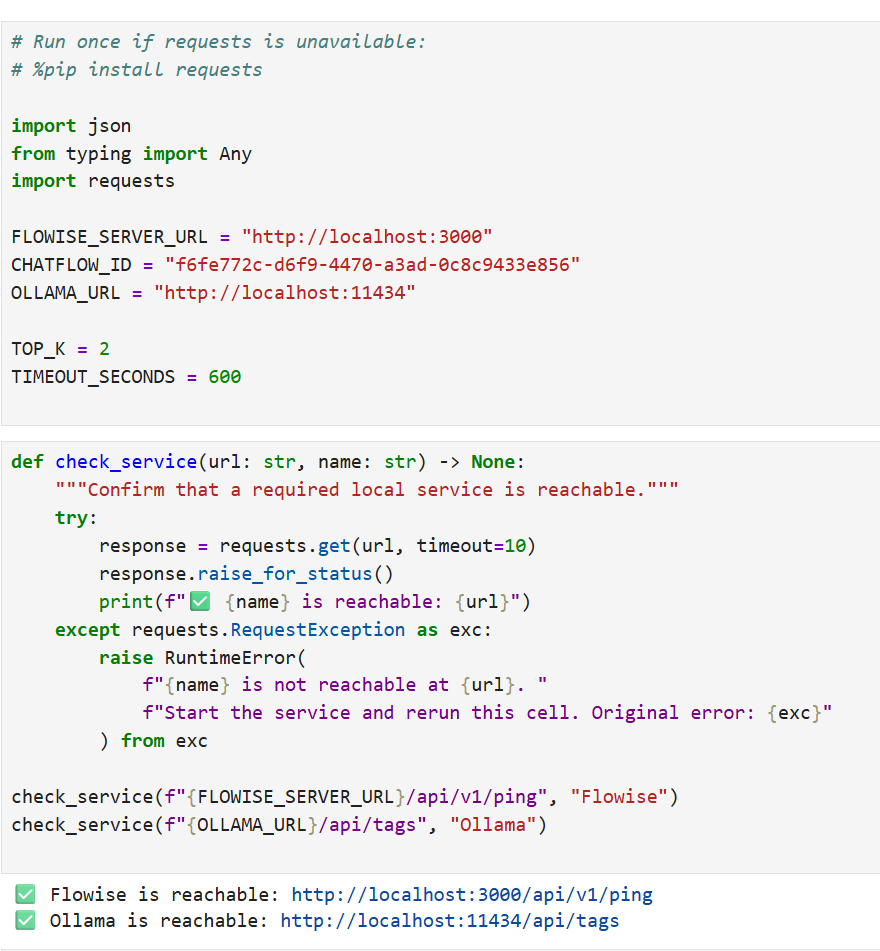

### Figure 2. Required Local Ollama Models

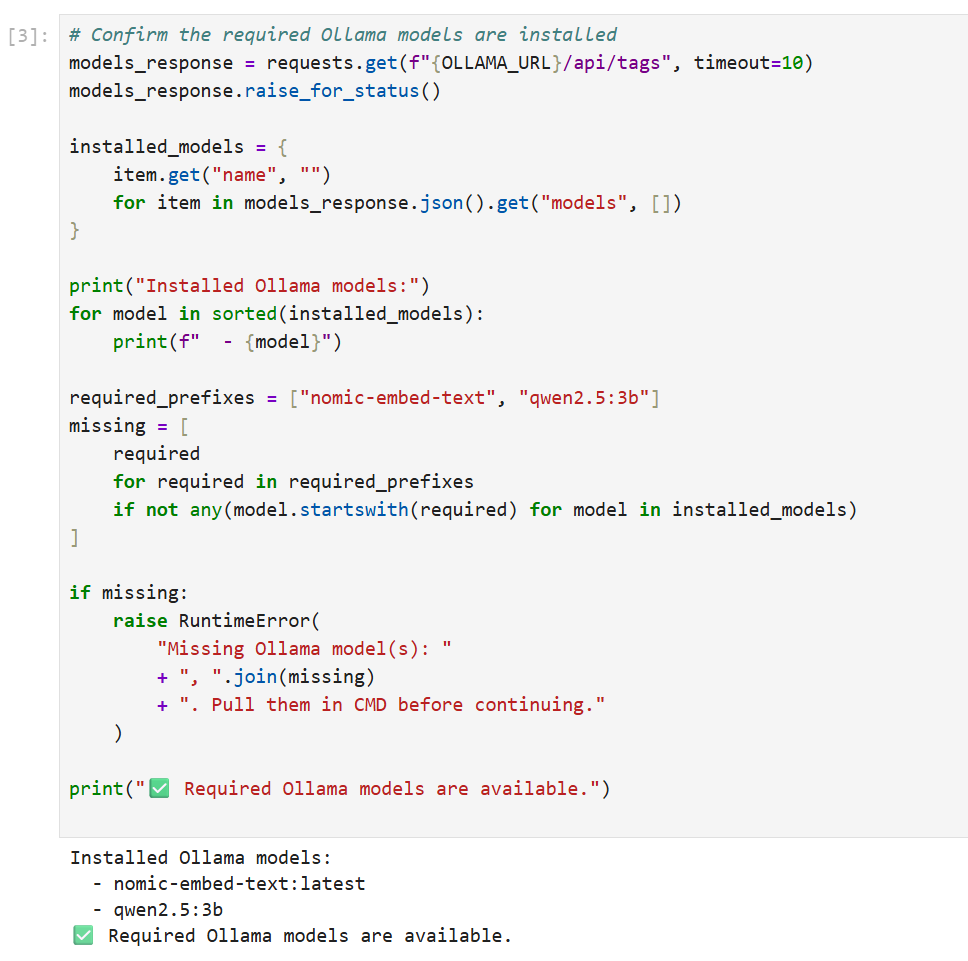

### Figure 3. Flowise Prediction API Test

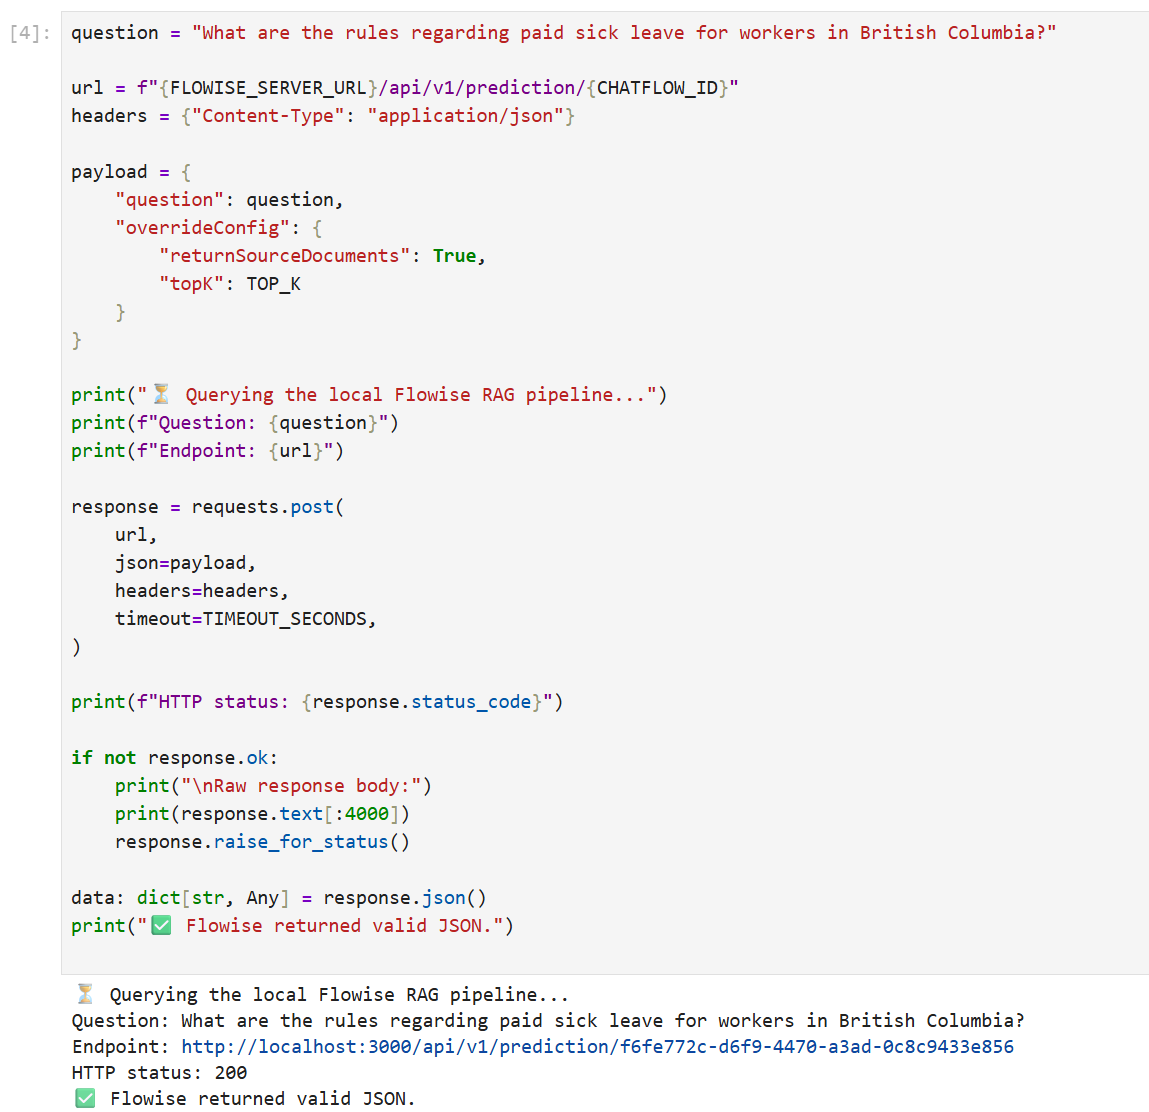

### Figure 4. Raw Retrieval Results and Source Metadata

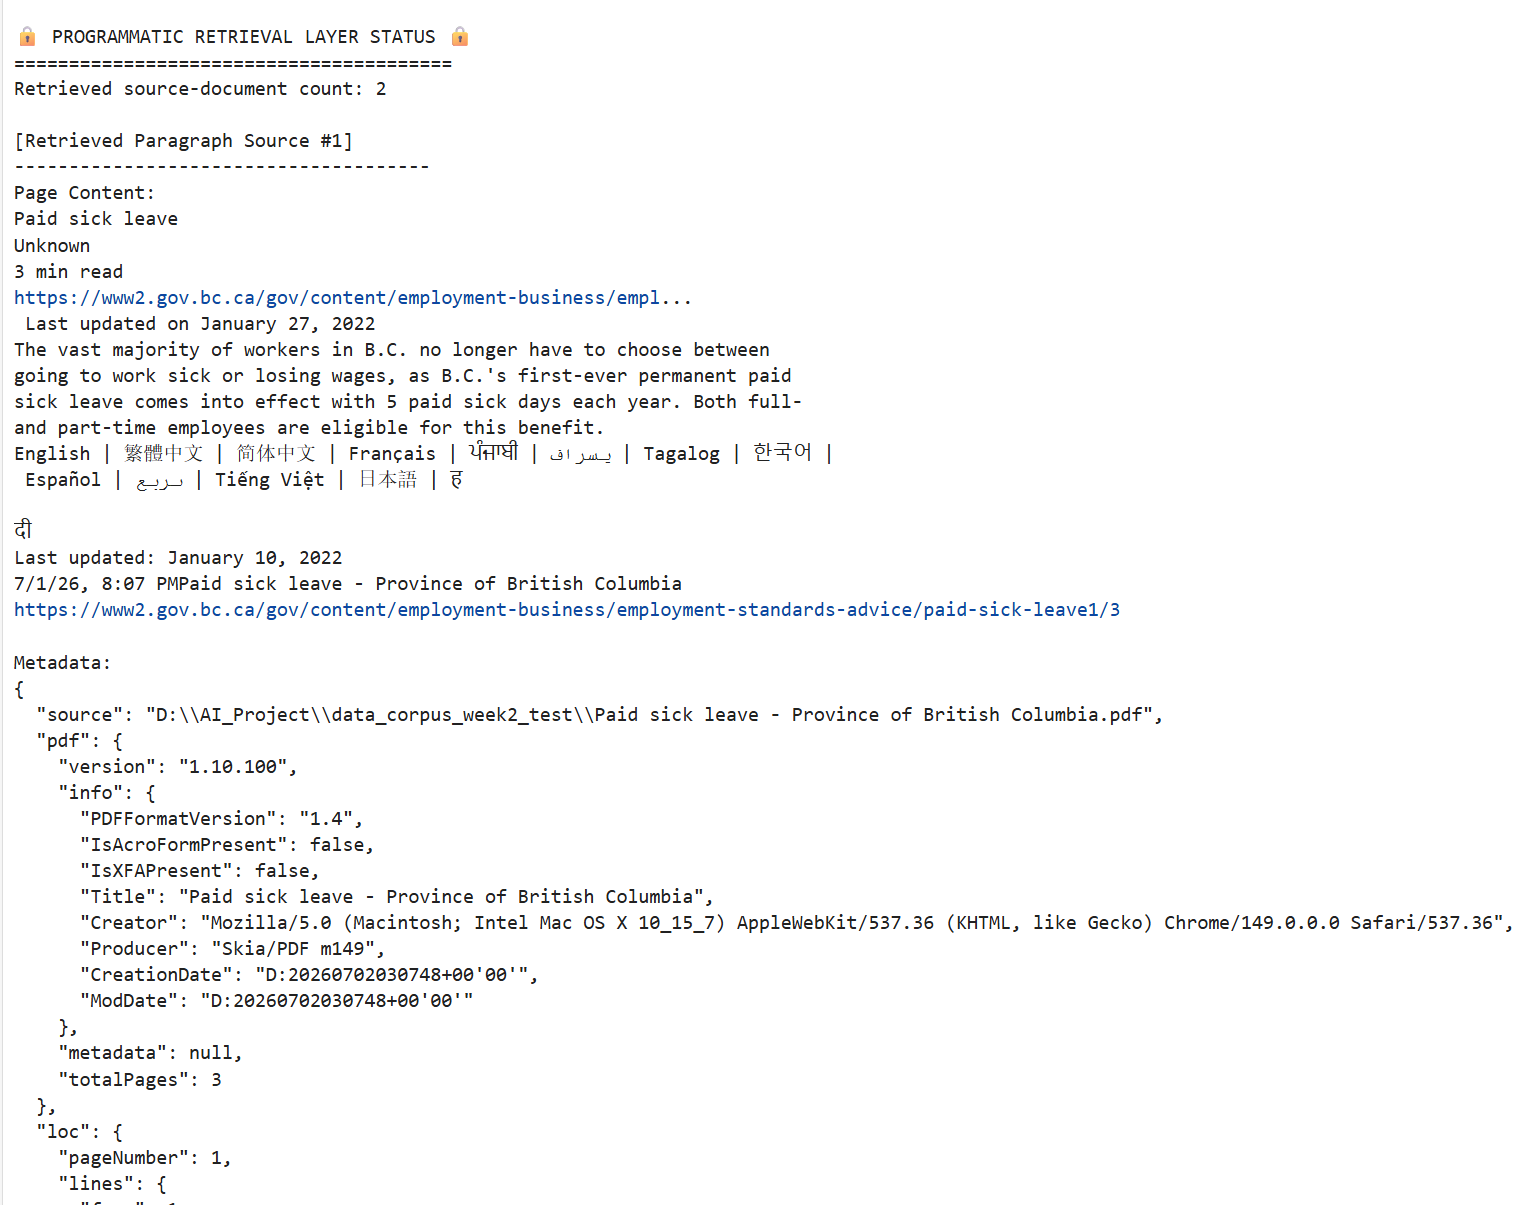

## Troubleshooting

### HTTP 401 from `/api/v1/vector/internal`

That is the old/internal endpoint used in the guide. Do not use it with this Flowise 2.2.7 setup. Use the Prediction API cell in this notebook.

### HTTP 404

Confirm the current Chatflow ID from the Flowise canvas URL and update `CHATFLOW_ID`.

### HTTP 500 or timeout

The first run may process all 69 PDFs and can be slow. Keep Flowise and Ollama running and allow several minutes.

### Source count is zero

- Open the Conversational Retrieval QA Chain.
- Turn on **Return Source Documents**.
- Confirm:
  - Folder path: `D:\AI_Project\data_corpus_final`
  - Embedding model: `nomic-embed-text`
  - Chat model: `qwen2.5:3b`
- Save the chatflow.
- Rerun the request cell.

### Imported JSON created a new ID

Copy the new ID from:

```text
http://localhost:3000/canvas/<NEW_CHATFLOW_ID>
```

and replace `CHATFLOW_ID`.


## Week 2 Result Interpretation

The Flowise Prediction API executed successfully and returned HTTP status
200 together with two source documents. This confirms that the local
retrieval pipeline is operational.

However, the Scotiabank question concerns a federally regulated bank,
while both retrieved passages came from the BC Provincial corpus.
Therefore, the technical retrieval test passed, but jurisdiction-aware
retrieval failed for this Federal banking query.

This failure is retained as evidence for the Week 4 evaluation and
root-cause analysis.